
# 3 Modeling & Forecasting (Baseline vs ML vs ARIMA/ARIMAX)


# ฝาก
- Setup: Train on <= CUTOFF_YEAR, test on > CUTOFF_YEAR for each selected country.

- Country selection strategy:
  We do not run ARIMA/ARIMAX for all ~140 countries. Instead, we evaluate a small,
  representative panel of countries chosen to cover different structural regimes:

  1. High historical emissions / mature economy
     - Example country: United States
     - Rationale: Large, stable, high baseline CO₂ emissions and energy consumption.

  2. Fast-growing industrializing emitters
     - Example countries: China, India
     - Rationale: Rapid economic and industrial expansion; strong upward CO₂ trend.

  3. Fossil-export / energy-intensive economies
     - Example countries: Russia, Saudi Arabia
     - Rationale: CO₂ levels driven by fossil fuel production and energy intensity,
       not just population or domestic consumption.

  4. Transition / decarbonizing advanced economy
     - Example countries: Germany, United Kingdom
     - Rationale: Active climate/energy policy and structural decline in emissions
       (can ARIMAX capture downward trends, or does it overfit past levels?).

  5. Emerging middle-income economy in Southeast Asia
     - Example countries: Thailand, Vietnam
     - Rationale: Moderate but rising CO₂; growth is not as extreme as China/India,
       and energy mix is still evolving.


- Goal:
  For each of these country types, we fit:
    • Naive (last observed),
    • Linear (Year + features),
    • ARIMA (univariate),
    • ARIMAX (with exogenous drivers like GDP, energy, population),
  and compare RMSE, MAE, MAPE, and R².

- Why this design matters:
  This lets us answer:
    "Which model works best for forecasting one country’s future?"
    AND
    "Does model performance depend on the country's structural profile
     (e.g. stable vs growing vs policy-transition vs shock)?"

In [2]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ARIMA/ARIMAX (auto order selection)
from pmdarima import auto_arima

warnings.filterwarnings("ignore")

# Display options
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (8,4)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## 1) Load cleaned panel data & Config

In [2]:

# Path to the cleaned data created by your pipeline
DATA_PATH = "cleaned_EDA_ready_timeseries.csv"

df = pd.read_csv(DATA_PATH)
df = df.sort_values(["Country Name","Year"]).reset_index(drop=True)

print("Shape:", df.shape, "| Years:", df["Year"].min(), "→", df["Year"].max(),
      "| Countries:", df["Country Name"].nunique())

# ===== CONFIG =====
TARGET = "CO2_total_mt"      # or "CO2_per_capita_ton"
CUTOFF_YEAR = 2015           # train <= cutoff, test > cutoff
COUNTRY = None               # set specific country or None to auto-pick most-complete

# Core features ONLY (no log columns here)
CORE_FEATS = [
    "GDP_current_usd",
    "Population_total",
    "LifeExp_years",
    "Energy_use_kg_oil_pc",
    "Renewable_energy_pct"
]


Shape: (7830, 14) | Years: 1970 → 2023 | Countries: 145


## 2) Helper functions

In [3]:

def rmse(y_true, y_pred): 
    import numpy as np
    from sklearn.metrics import mean_squared_error
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred): 
    from sklearn.metrics import mean_absolute_error
    return float(mean_absolute_error(y_true, y_pred))

def r2(y_true, y_pred): 
    from sklearn.metrics import r2_score
    return float(r2_score(y_true, y_pred))

def mape(y_true, y_pred):
    import numpy as np
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    eps = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)

def summarize_metrics(y_true, y_pred, name):
    return {"model": name,
            "RMSE": rmse(y_true, y_pred),
            "MAE":  mae(y_true, y_pred),
            "MAPE%": mape(y_true, y_pred),
            "R2":   r2(y_true, y_pred)}

def plot_actual_pred(year, y_true, y_pred, title="Forecast vs Actual", ylabel=None):
    import numpy as np, matplotlib.pyplot as plt
    year   = np.asarray(year)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    assert len(year)==len(y_true)==len(y_pred),f"Length mismatch: year={len(year)}, y_true={len(y_true)}, y_pred={len(y_pred)}"
    plt.figure(figsize=(8,4))
    plt.plot(year, y_true, label="Actual")
    plt.plot(year, y_pred, label="Pred")
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel or TARGET)
    plt.legend()
    plt.tight_layout()
    plt.show()

def add_lags_roll(g: pd.DataFrame, target: str, lags=(1,2,3), rolls=(3,)):
    g = g.sort_values("Year").copy()
    for L in lags:
        g[f"{target}_lag{L}"] = g[target].shift(L)
    for r in rolls:
        g[f"{target}_roll{r}"] = g[target].rolling(r).mean()
    return g


## 3) Select one country & prepare data

In [4]:

# Auto-pick the most complete country if not provided
if COUNTRY is None:
    COUNTRY = df["Country Name"].value_counts().index[0]

print("Country:", COUNTRY)

# Keep only core features + target
cols_needed = ["Year", TARGET] + CORE_FEATS
d = (df[df["Country Name"]==COUNTRY][cols_needed]
       .dropna(subset=[TARGET])
       .sort_values("Year")
       .reset_index(drop=True))

# Split by time
train = d[d["Year"] <= CUTOFF_YEAR].copy()
test  = d[d["Year"]  > CUTOFF_YEAR].copy()

if test.empty or train.empty:
    raise ValueError("Train/test split is empty. Adjust CUTOFF_YEAR or ensure the selected country has enough data.")

print(f"{COUNTRY} | Train {train.Year.min()}–{train.Year.max()} | Test {test.Year.min()}–{test.Year.max()}")

# Exogenous scaler (for ARIMAX)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtr_exo = scaler.fit_transform(train[CORE_FEATS])
Xte_exo = scaler.transform(test[CORE_FEATS])

ytr = train[TARGET].values
yte = test[TARGET].values


Country: Albania
Albania | Train 1970–2015 | Test 2016–2023


## 4) Baselines — Naive & Linear Regression

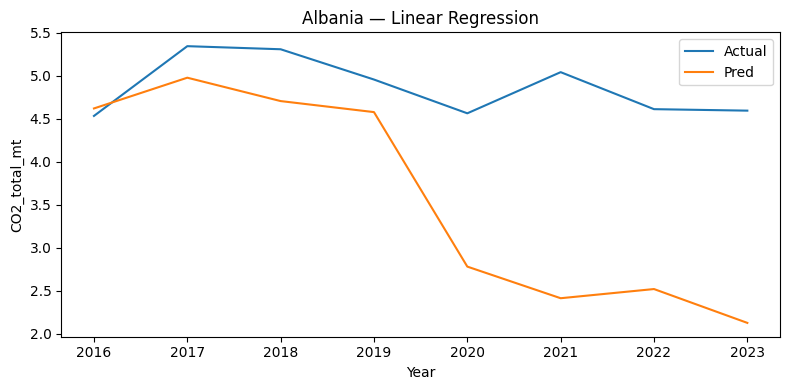

,model,RMSE,MAE,MAPE%,R2
0,Naive,0.3171,0.2935,6.0022,-0.0001
1,Linear+Features,1.6280,1.3008,27.2717,-25.3684


In [5]:

# 4.1 Naive
yhat_naive = np.repeat(ytr[-1], len(yte))
m_naive = summarize_metrics(yte, yhat_naive, "Naive")

# 4.2 Linear Regression (trend + core features)
from sklearn.linear_model import LinearRegression
Xtr = train[["Year"] + CORE_FEATS].values
Xte = test[["Year"] + CORE_FEATS].values

lin = LinearRegression().fit(Xtr, ytr)
yhat_lin = lin.predict(Xte)
m_lin = summarize_metrics(yte, yhat_lin, "Linear+Features")

plot_actual_pred(test["Year"].values, yte, yhat_lin, f"{COUNTRY} — Linear Regression")
pd.DataFrame([m_naive, m_lin]).sort_values("RMSE")


## 5) Statistical — ARIMA (univariate) & ARIMAX (+ exogenous)

Best ARIMA order (univariate): (2, 0, 0)


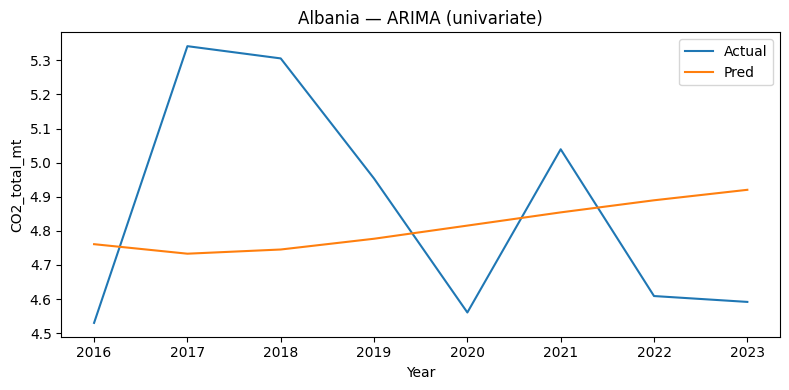

Best ARIMAX order: (2, 0, 0)


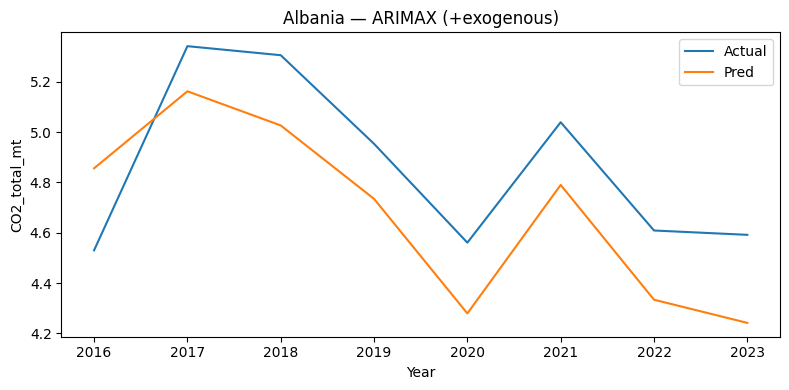

,model,RMSE,MAE,MAPE%,R2
1,ARIMAX(+exo),0.2746,0.2698,5.6156,0.2497
0,ARIMA(univariate),0.3630,0.3281,6.6385,-0.3110


In [6]:

from pmdarima import auto_arima

# 5.1 ARIMA (univariate)
arima_uni = auto_arima(ytr, seasonal=False, stepwise=True,
                       max_p=5, max_q=5, max_d=2,
                       information_criterion="aic",
                       suppress_warnings=True)
print("Best ARIMA order (univariate):", arima_uni.order)

yhat_uni = arima_uni.predict(n_periods=len(yte))
m_uni = summarize_metrics(yte, yhat_uni, "ARIMA(univariate)")
plot_actual_pred(test["Year"].values, yte, yhat_uni, f"{COUNTRY} — ARIMA (univariate)")

# 5.2 ARIMAX (+ exogenous)
arimax = auto_arima(y=ytr, X=Xtr_exo, seasonal=False, stepwise=True,
                    max_p=5, max_q=5, max_d=2,
                    information_criterion="aic",
                    suppress_warnings=True)
print("Best ARIMAX order:", arimax.order)

yhat_arimax = arimax.predict(n_periods=len(yte), X=Xte_exo)
m_arimax = summarize_metrics(yte, yhat_arimax, "ARIMAX(+exo)")
plot_actual_pred(test["Year"].values, yte, yhat_arimax, f"{COUNTRY} — ARIMAX (+exogenous)")

pd.DataFrame([m_uni, m_arimax]).sort_values("RMSE")


## 6) Machine Learning — RandomForest & XGBoost (with target lags/rolling)

ML features: 10 → ['Year', 'GDP_current_usd', 'Population_total', 'LifeExp_years', 'Energy_use_kg_oil_pc', 'Renewable_energy_pct', 'CO2_total_mt_lag1', 'CO2_total_mt_lag2', 'CO2_total_mt_lag3'] ...


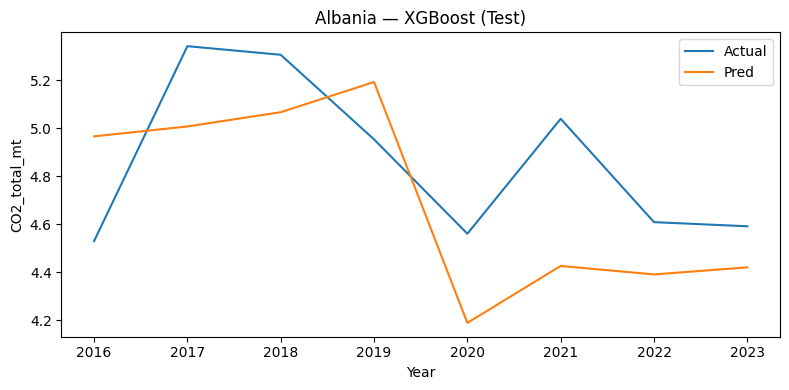

,model,RMSE,MAE,MAPE%,R2
1,XGBoost (Test),0.3545,0.3275,6.7429,-0.2503
0,RandomForest (Test),0.4168,0.3622,7.6507,-0.7284


In [7]:

# Build lag/rolling features for TARGET (per-country)
d_ml = add_lags_roll(d, TARGET, lags=(1,2,3), rolls=(3,))

# Only keep core features + lags/rolling (NO log columns)
lag_cols = [c for c in d_ml.columns if c.startswith(TARGET+"_")]  # e.g., CO2_total_mt_lag1, lag2, roll3
FEATS_ML = CORE_FEATS + lag_cols

# Drop rows where any feature or target is NA
d_ml = d_ml.dropna(subset=[TARGET] + FEATS_ML).reset_index(drop=True)

train_ml = d_ml[d_ml["Year"] <= CUTOFF_YEAR].copy()
test_ml  = d_ml[d_ml["Year"]  > CUTOFF_YEAR].copy()

if test_ml.empty or train_ml.empty:
    raise ValueError("Train/test ML split is empty after adding lags. Adjust cutoffs or ensure enough history.")

Xtr_ml, ytr_ml = train_ml[["Year"] + FEATS_ML].values, train_ml[TARGET].values
Xte_ml, yte_ml = test_ml[["Year"] + FEATS_ML].values,  test_ml[TARGET].values

print("ML features:", len(FEATS_ML)+1, "→", ["Year"]+FEATS_ML[:8], "...")

# Random Forest
rf = RandomForestRegressor(
    n_estimators=800, max_depth=None, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(Xtr_ml, ytr_ml)
yhat_rf = rf.predict(Xte_ml)
m_rf = summarize_metrics(yte_ml, yhat_rf, "RandomForest (Test)")

# XGBoost
xgb = XGBRegressor(
    n_estimators=800, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror",
    random_state=42, n_jobs=-1
)
xgb.fit(Xtr_ml, ytr_ml)
yhat_xgb = xgb.predict(Xte_ml)
m_xgb = summarize_metrics(yte_ml, yhat_xgb, "XGBoost (Test)")

# Plot best ML
best_name = "RandomForest (Test)" if m_rf["RMSE"] <= m_xgb["RMSE"] else "XGBoost (Test)"
best_pred = yhat_rf if best_name.startswith("RandomForest") else yhat_xgb
plot_actual_pred(test_ml["Year"].values, yte_ml, best_pred, f"{COUNTRY} — {best_name}")

pd.DataFrame([m_rf, m_xgb]).sort_values("RMSE")


## 7) Comparison summary

,model,RMSE,MAE,MAPE%,R2
3,ARIMAX(+exo),0.2746,0.2698,5.6156,0.2497
0,Naive,0.3171,0.2935,6.0022,-0.0001
5,XGBoost (Test),0.3545,0.3275,6.7429,-0.2503
2,ARIMA(univariate),0.3630,0.3281,6.6385,-0.3110
4,RandomForest (Test),0.4168,0.3622,7.6507,-0.7284
1,Linear+Features,1.6280,1.3008,27.2717,-25.3684


<Figure size 1000x500 with 0 Axes>

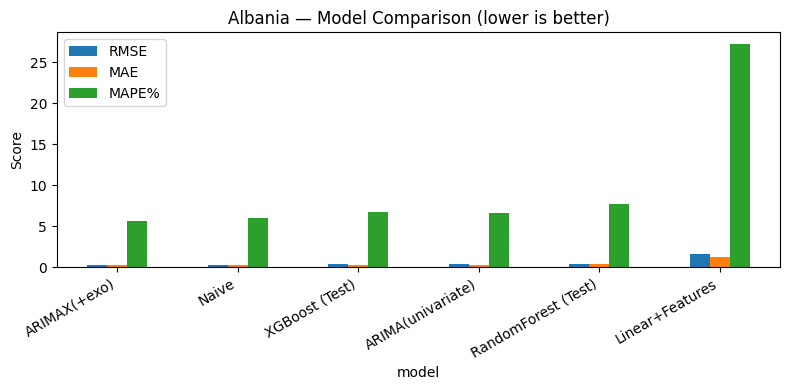

In [8]:

df_compare = pd.DataFrame([m_naive, m_lin, m_uni, m_arimax, m_rf, m_xgb]).sort_values("RMSE")
display(df_compare)

# Bar plot (lower is better)
plt.figure(figsize=(10,5))
df_compare.set_index("model")[["RMSE","MAE","MAPE%"]].plot(kind="bar")
plt.title(f"{COUNTRY} — Model Comparison (lower is better)")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()


## 8) (Optional) Forecast to 2030 with ARIMAX (+scenario for exogenous)

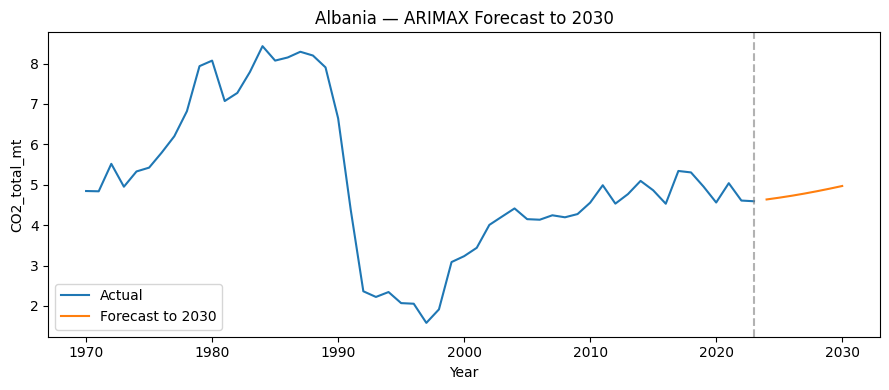

In [9]:

# Build simple exogenous scenario for future years (e.g., constant growth)
def build_future_exo(last_row: pd.Series, years: list, annual_growth=None):
    rows = []
    cur = last_row.copy()
    for _ in years:
        if annual_growth:
            for k,g in (annual_growth.items() if isinstance(annual_growth, dict) else []):
                cur[k] = cur[k] * (1.0 + g)
        rows.append(cur.copy())
    return pd.DataFrame(rows)[CORE_FEATS]

last_year = int(d["Year"].max())
future_years = list(range(last_year+1, 2031))

growth = {"GDP_current_usd": 0.02, "Population_total": 0.01}  # sample scenario
last_feat = d[CORE_FEATS].iloc[-1]

# Fit ARIMAX on all available history
X_all = StandardScaler().fit_transform(d[CORE_FEATS])
arimax_full = auto_arima(y=d[TARGET].values, X=X_all, seasonal=False, stepwise=True,
                         max_p=5, max_q=5, max_d=2, information_criterion="aic",
                         suppress_warnings=True)

future_exo = build_future_exo(last_feat, future_years, annual_growth=growth)
future_exo_scaled = StandardScaler().fit(d[CORE_FEATS]).transform(future_exo)

fc_2030 = arimax_full.predict(n_periods=len(future_years), X=future_exo_scaled)

plt.figure(figsize=(9,4))
plt.plot(d["Year"], d[TARGET], label="Actual")
plt.plot(future_years, fc_2030, label="Forecast to 2030")
plt.axvline(x=last_year, ls="--", c="gray", alpha=0.6)
plt.title(f"{COUNTRY} — ARIMAX Forecast to 2030")
plt.xlabel("Year"); plt.ylabel(TARGET); plt.legend(); plt.tight_layout(); plt.show()


Shape: (7830, 14) | Years: 1970 → 2023 | Countries: 145
Train rows: 6,063  |  Test rows: 1,128
                 model     RMSE     MAE  MAPE%     R2
0  Global-RandomForest 185.1245 22.0055 3.3381 0.9723
1       Global-XGBoost 301.0463 40.5100 6.3918 0.9267

=== Top-10 countries (lowest RMSE) — RandomForest ===


,Country Name,RMSE,MAE,MAPE%,n_years,model
41,Eritrea,0.0153,0.0129,1.9595,8,Global-RandomForest
43,Eswatini,0.0369,0.0294,2.5320,8,Global-RandomForest
81,Mauritius,0.0836,0.0547,1.3894,8,Global-RandomForest
88,Namibia,0.0893,0.0749,1.8208,8,Global-RandomForest
108,Rwanda,0.0910,0.0689,4.3708,8,Global-RandomForest
129,Uganda,0.0999,0.0784,1.1288,8,Global-RandomForest
56,Iceland,0.1041,0.0944,2.9662,8,Global-RandomForest
93,Niger,0.1089,0.0939,3.6964,8,Global-RandomForest
23,Chad,0.1130,0.0873,4.1350,8,Global-RandomForest
4,Armenia,0.1139,0.0943,1.4956,8,Global-RandomForest



=== Bottom-10 countries (highest RMSE) — RandomForest ===


,Country Name,RMSE,MAE,MAPE%,n_years,model
25,China,"2,103.6425","1,928.1116",15.7289,8,Global-RandomForest
57,India,531.9472,402.4675,15.6846,8,Global-RandomForest
133,United States,329.0097,268.1536,5.6723,8,Global-RandomForest
65,Japan,62.6434,57.1061,5.3092,8,Global-RandomForest
107,Russian Federation,59.4900,53.9377,2.8355,8,Global-RandomForest
49,Germany,52.8260,42.5911,6.2460,8,Global-RandomForest
58,Indonesia,28.0253,24.1794,4.0267,8,Global-RandomForest
137,Viet Nam,24.7173,19.7186,6.2715,8,Global-RandomForest
22,Canada,22.6089,15.2820,2.6632,8,Global-RandomForest
69,"Korea, Rep.",20.4875,16.5342,2.6827,8,Global-RandomForest


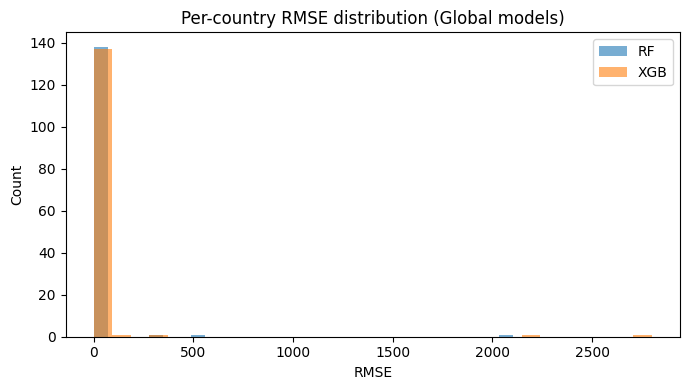

Saved: global_ml_overall_metrics.csv, global_rf_per_country_metrics.csv, global_xgb_per_country_metrics.csv


In [10]:
# ===================== GLOBAL ML MODEL (Panel / all countries) =====================
# 0) Setup
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ---------- Config ----------
DATA_PATH    = "cleaned_EDA_ready_timeseries.csv"
TARGET       = "CO2_total_mt"        # หรือ "CO2_per_capita_ton"
CUTOFF_YEAR  = 2015                  # train: Year <= CUTOFF_YEAR, test: Year > CUTOFF_YEAR

CORE_FEATS = [
    "GDP_current_usd",
    "Population_total",
    "LifeExp_years",
    "Energy_use_kg_oil_pc",
    "Renewable_energy_pct",
]

# ---------- Utils ----------
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    eps = 1e-9
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def summarize(y_true, y_pred, name):
    return {
        "model": name,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "MAPE%": mape(y_true, y_pred),
        "R2":   r2_score(y_true, y_pred),
    }

def add_lags_roll_per_country(df, target, lags=(1,2,3), rolls=(3,)):
    df = df.sort_values(["Country Name","Year"]).copy()
    grp = df.groupby("Country Name")[target]
    # create lags/rolling using only within-country history -> no leakage
    for L in lags:
        df[f"{target}_lag{L}"] = grp.shift(L)
    for r in rolls:
        df[f"{target}_roll{r}"] = grp.transform(lambda s: s.rolling(window=r, min_periods=r).mean())
    return df

# 1) Load & prepare panel
df = pd.read_csv(DATA_PATH).sort_values(["Country Name","Year"]).reset_index(drop=True)
print("Shape:", df.shape, "| Years:", df["Year"].min(), "→", df["Year"].max(),
      "| Countries:", df["Country Name"].nunique())

# สร้าง lag/rolling ของ TARGET ต่อประเทศ
df = add_lags_roll_per_country(df, TARGET, lags=(1,2,3), rolls=(3,))
lag_cols = [c for c in df.columns if c.startswith(TARGET+"_")]  # lag1/lag2/lag3/roll3

# เลือกฟีเจอร์หลัก + lag features + Year (+Country Code แบบ one-hot)
FEATS_NUM  = ["Year"] + CORE_FEATS + lag_cols
FEATS_CAT  = ["Country Code"]     # country context ให้โมเดลรู้ว่าประเทศไหน
FEATS_ALL  = FEATS_NUM + FEATS_CAT

# ลบแถวที่ target หรือฟีเจอร์สำคัญขาด
df_ml = df.dropna(subset=[TARGET] + FEATS_NUM).copy()

# 2) Time-based split สำหรับทุกประเทศ (train: <= cutoff, test: > cutoff)
train = df_ml[df_ml["Year"] <= CUTOFF_YEAR].copy()
test  = df_ml[df_ml["Year"]  > CUTOFF_YEAR].copy()
print(f"Train rows: {len(train):,}  |  Test rows: {len(test):,}")

Xtr_num, Xte_num = train[FEATS_NUM], test[FEATS_NUM]
Xtr_cat, Xte_cat = train[FEATS_CAT], test[FEATS_CAT]
ytr, yte = train[TARGET].values, test[TARGET].values

# 3) Pipelines: (a) RandomForest (ไม่ต้องสเกล), (b) XGBoost (ไม่ต้องสเกลก็ได้)
#    แต่เราจะทำ ColumnTransformer เพื่อ one-hot 'Country Code'
preprocess_for_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", FEATS_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATS_CAT),
    ],
    remainder="drop",
)

rf_model = Pipeline(steps=[
    ("prep", preprocess_for_tree),
    ("rf", RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model = Pipeline(steps=[
    ("prep", preprocess_for_tree),
    ("xgb", XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# 4) Train & evaluate (overall)
rf_model.fit(train[FEATS_ALL], ytr)
yhat_rf = rf_model.predict(test[FEATS_ALL])
m_rf = summarize(yte, yhat_rf, "Global-RandomForest")

xgb_model.fit(train[FEATS_ALL], ytr)
yhat_xgb = xgb_model.predict(test[FEATS_ALL])
m_xgb = summarize(yte, yhat_xgb, "Global-XGBoost")

print(pd.DataFrame([m_rf, m_xgb]).sort_values("RMSE"))

# 5) รายงานผล “รายประเทศ” เพื่อดูว่าใครดี/แย่
def per_country_report(df_test, y_true, y_pred, name):
    out = df_test[["Country Name","Year"]].copy()
    out["y_true"] = y_true
    out["y_pred"] = y_pred

    def rmse_s(s):  # s = y_true ของกลุ่มนั้น
        yp = out.loc[s.index, "y_pred"]
        return float(np.sqrt(np.mean((s - yp)**2)))

    def mae_s(s):
        yp = out.loc[s.index, "y_pred"]
        return float(np.mean(np.abs(s - yp)))

    def mape_s(s):
        yp = out.loc[s.index, "y_pred"]
        return float(np.mean(np.abs((s - yp) / np.maximum(np.abs(s), 1e-9))) * 100)

    grp = out.groupby("Country Name").agg(
        RMSE=("y_true", rmse_s),
        MAE =("y_true", mae_s),
        MAPE=("y_true", mape_s),
        n_years=("y_true", "size"),
    ).reset_index()
    grp = grp.rename(columns={"MAPE": "MAPE%"})
    grp["model"] = name
    return grp


rep_rf  = per_country_report(test, yte, yhat_rf,  "Global-RandomForest")
rep_xgb = per_country_report(test, yte, yhat_xgb, "Global-XGBoost")

# Top/Bottom ประเทศตาม RMSE
print("\n=== Top-10 countries (lowest RMSE) — RandomForest ===")
display(rep_rf.sort_values("RMSE").head(10))
print("\n=== Bottom-10 countries (highest RMSE) — RandomForest ===")
display(rep_rf.sort_values("RMSE", ascending=False).head(10))

# 6) Plot: Error distribution
plt.figure(figsize=(7,4))
plt.hist(rep_rf["RMSE"], bins=30, alpha=0.6, label="RF")
plt.hist(rep_xgb["RMSE"], bins=30, alpha=0.6, label="XGB")
plt.title("Per-country RMSE distribution (Global models)")
plt.xlabel("RMSE"); plt.ylabel("Count"); plt.legend(); plt.tight_layout(); plt.show()

# 7) บันทึกผลรวม
pd.DataFrame([m_rf, m_xgb]).to_csv("global_ml_overall_metrics.csv", index=False)
rep_rf.to_csv("global_rf_per_country_metrics.csv", index=False)
rep_xgb.to_csv("global_xgb_per_country_metrics.csv", index=False)
print("Saved: global_ml_overall_metrics.csv, global_rf_per_country_metrics.csv, global_xgb_per_country_metrics.csv")
